In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained('/kaggle/input/distillbert-multilingual/transformers/default/1', trust_remote_code=True, num_labels=3)
tokenizer = AutoTokenizer.from_pretrained('/kaggle/input/distillbert-multilingual/transformers/default/1', trust_remote_code=True)
# model = AutoModelForSequenceClassification.from_pretrained('/kaggle/input/distillbert-multilingual/transformers/classification/1', trust_remote_code=True, num_labels=3)
# tokenizer = AutoTokenizer.from_pretrained('/kaggle/input/distillbert-multilingual/transformers/classification/1', trust_remote_code=True)

2025-12-28 15:04:40.420319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766934280.806731      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766934280.913965      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/distillbert-multilingual/transformers/default/1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250037, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1

In [3]:
from datasets import DatasetDict, Dataset
import numpy as np
import pandas as pd

train_data = pd.read_csv('/kaggle/input/contradictory-my-dear-watson/train.csv')
test_data = pd.read_csv('/kaggle/input/contradictory-my-dear-watson/test.csv')

def tokenize_function(example, tokenizer):
    return tokenizer(example['text'], truncation=True, padding=True, max_length=256)
def create_text(df):
    sep_token = tokenizer.special_tokens_map['sep_token']
    df['text'] = df.apply(lambda x: (
        f"Premise:\n"
        f"{x['premise']}\n"
        f"{sep_token}\n"
        f"Hypothesis:\n"
        f"{x['hypothesis']}"
    ), axis=1)    


create_text(train_data)
create_text(test_data)
train_data = Dataset.from_pandas(train_data).map(lambda example: tokenize_function(example, tokenizer), batched=True)    
test_data = Dataset.from_pandas(test_data).map(lambda example: tokenize_function(example, tokenizer), batched=True)    


def split_hf_by_train_val(hf_dataset):
    train_test_split = hf_dataset.train_test_split(test_size=0.1, shuffle=True, seed=42)
    train_dataset = train_test_split['train']
    val_dataset = train_test_split['test']
    return DatasetDict({
            'train': train_dataset,
            'validation': val_dataset
    })

    
train_data = split_hf_by_train_val(train_data)

Map:   0%|          | 0/12120 [00:00<?, ? examples/s]

Map:   0%|          | 0/5195 [00:00<?, ? examples/s]

In [4]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef    
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    results = {}
    
    # Accuracy
    results["accuracy"] = accuracy_score(labels, preds)
    
    # F1 (macro + weighted)
    results["f1_macro"] = f1_score(labels, preds, average="macro")
    results["f1_micro"] = f1_score(labels, preds, average="micro")
    results["f1_weighted"] = f1_score(labels, preds, average="weighted")
    
    # Precision / Recall (macro)
    results["precision_macro"] = precision_score(labels, preds, average="macro")
    results["recall_macro"] = recall_score(labels, preds, average="macro")
    
    # MCC
    results["mcc"] = matthews_corrcoef(labels, preds)

    return results



from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


BATCH_SIZE=16
training_args = TrainingArguments(
    # output_dir='./kaggle/working/results',    
    eval_strategy='epoch',
    save_strategy='epoch',    
    num_train_epochs=5, 
    warmup_ratio=0.1,
    lr_scheduler_type='warmup_stable_decay',        
    optim = 'adamw_torch_fused',        
    per_device_train_batch_size=BATCH_SIZE,        
        
    
    learning_rate=5e-5, # по логарифмической
    weight_decay=0.01, 
    lr_scheduler_kwargs={
        'num_decay_steps':  3 * len(train_data['train']) // BATCH_SIZE, # можно поиграться
    },
    max_grad_norm=1.0, # значение из вывода обучения (это максимальная норма, которая была достигнута) можно варьировать от 1 до max
    

    # ускорение
    torch_compile=True,
    torch_compile_backend="inductor",
    torch_compile_mode="default",

    # logging_strategy="epoch",        
    # log_level="passive",          
    # log_level_replica="passive",  

    log_level="passive",                    
    logging_strategy="epoch",        
    logging_nan_inf_filter=True,     
    
    
    seed=42,
    
    save_total_limit=1,
    load_best_model_at_end=True,


    
    # maybe better result via metric optimization
    metric_for_best_model="accuracy",
    greater_is_better=True,  
    
    # maybe better result via generalization
    # metric_for_best_model='eval_loss',
    # greater_is_better=False,
        

    
    # logging_dir='./kaggle/working/logs',
    report_to='none',        
)

    
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data['train'],
    eval_dataset=train_data['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,    
    compute_metrics=compute_metrics,        
)
trainer.train()

The speedups for torchdynamo mostly come with GPU Ampere or higher and which is not detected here.
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro,F1 Weighted,Precision Macro,Recall Macro,Mcc
1,1.025100,0.882873,0.611386,0.599810,0.611386,0.604800,0.606742,0.603192,0.415522
2,0.831600,0.765117,0.665017,0.661399,0.665017,0.662452,0.674350,0.667300,0.505447
3,0.682300,0.728862,0.709571,0.703747,0.709571,0.706441,0.708295,0.705189,0.564986
4,0.562000,0.717737,0.721122,0.719704,0.721122,0.721623,0.720244,0.720517,0.582050
5,0.512200,0.722318,0.719472,0.717955,0.719472,0.719823,0.717932,0.718327,0.578829


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=1705, training_loss=0.7226215261867669, metrics={'train_runtime': 647.1652, 'train_samples_per_second': 84.275, 'train_steps_per_second': 2.635, 'total_flos': 1758213846121824.0, 'train_loss': 0.7226215261867669, 'epoch': 5.0})

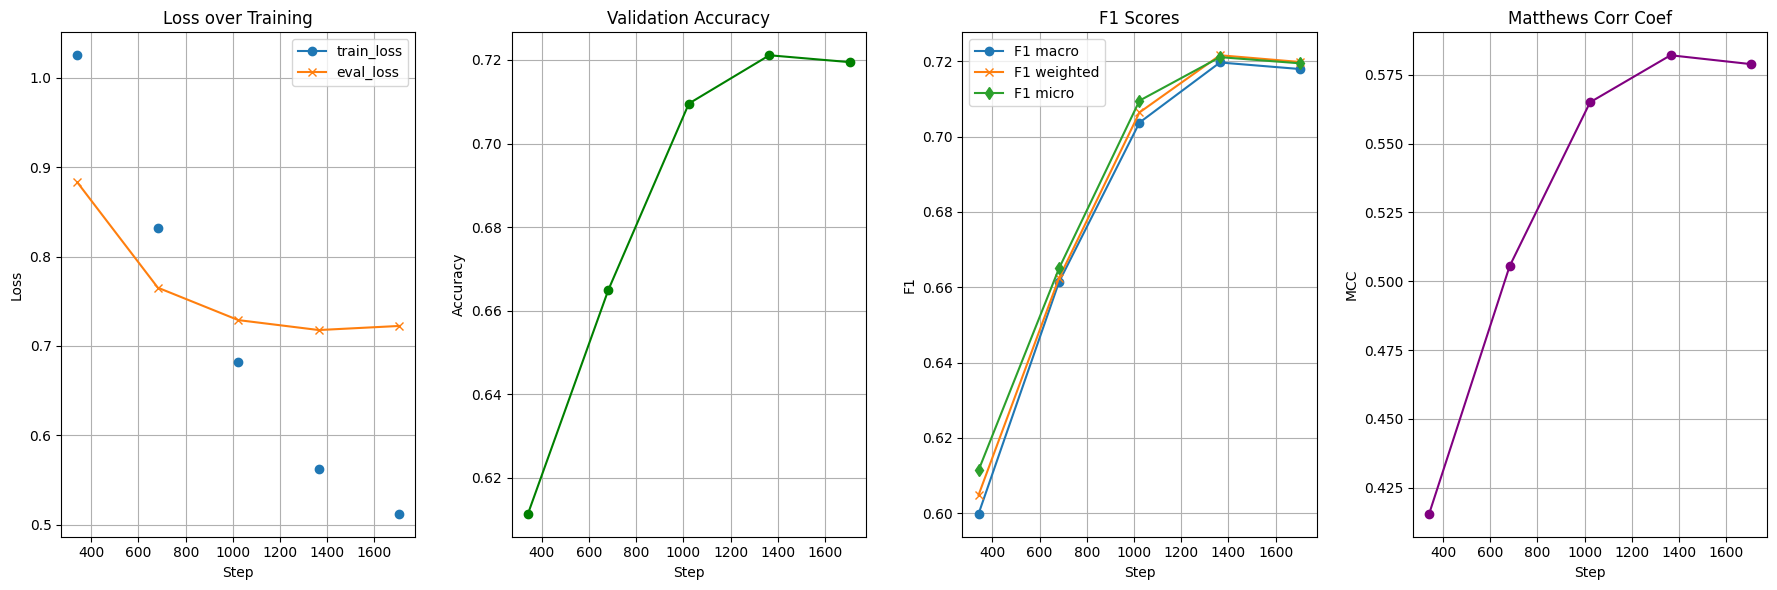

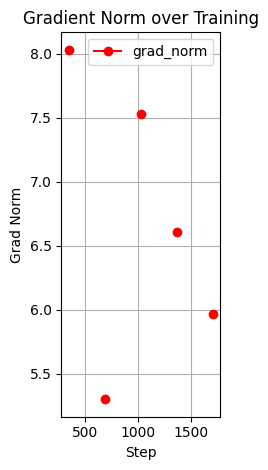

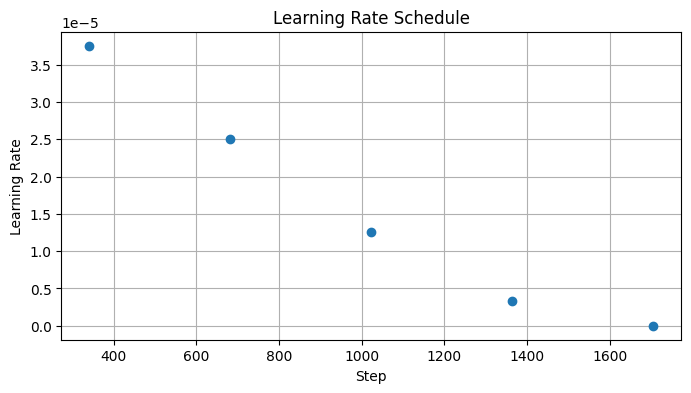

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TEST METRICS


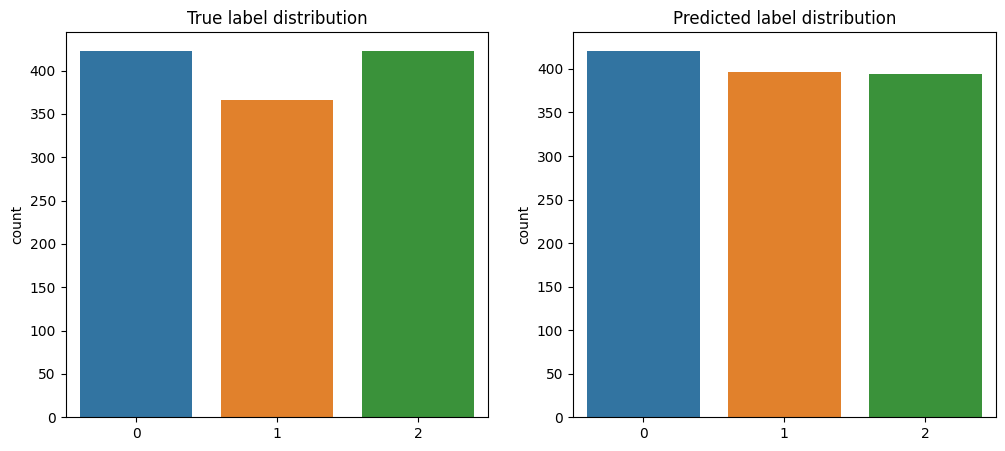

Language-wise accuracy:
Greek: 0.5349 (23/43)
English: 0.7360 (527/716)
Swahili: 0.5517 (16/29)
French: 0.7500 (30/40)
Arabic: 0.7447 (35/47)
Russian: 0.8000 (28/35)
Thai: 0.7778 (28/36)
Spanish: 0.7391 (17/23)
Hindi: 0.7333 (22/30)
Chinese: 0.6944 (25/36)
Vietnamese: 0.6750 (27/40)
Urdu: 0.7297 (27/37)
German: 0.6875 (22/32)
Bulgarian: 0.5484 (17/31)
Turkish: 0.8108 (30/37)


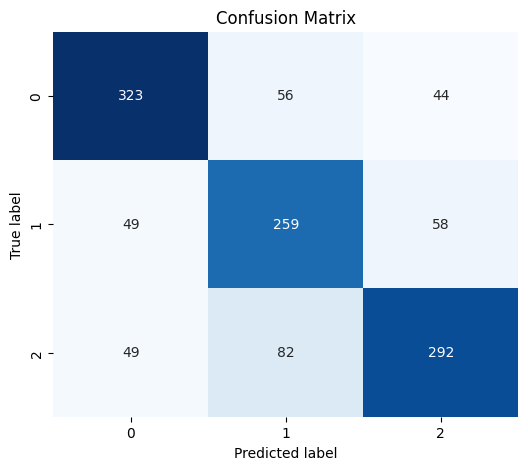


predicted as entailment but it is contradiction (total 49):


,text,true,pred
17,"Premise:\nC. P. Snow évoque les deux cultures, les sciences et les sciences humaines, qui jamais ne se mélangent.\n</s>\nHypothesis:\nC. P. Snow n'a jamais écrit sur les sciences et l'humanité.",2,0
22,"Premise:\nWhile headquarters staffing is to be streamlined, the staffing levels at the ports are to be maintained or increased.\n</s>\nHypothesis:\nHeadquarters staff is increased and port staff streamlined.",2,0
134,"Premise:\nA small page-boy was waiting outside her own door when she returned to it.\n</s>\nHypothesis:\nThe page-boy she'd been expecting was gone, having waited too long for her to return.",2,0
220,"Premise:\nOh, sorry, wrong church.\n</s>\nHypothesis:\nIt was the right church.",2,0
259,Premise:\nThe sacred is not mysterious to her.\n</s>\nHypothesis:\nThe woman does not know anything sacred.,2,0
275,"Premise:\nMore detailed implementation plans also will be necessary to address business system, processes, and resource issues.\n</s>\nHypothesis:\nLess detailed plans will be necessary to address business systems",2,0
296,Premise:\nbut how do you know the good from the bad\n</s>\nHypothesis:\nWhy care if it's good or bad?,2,0
323,"Premise:\nΤο pachuco ήταν περιφρονημένο στις Η.Π.Α. τόσο από την μεξικανοαμερικανική κοινότητα όσο και από αυτή των Anglo , και όπως στο Μεξικό από τα ΜΜΕ και τους διανοούμενους.\n</s>\nHypothesis:\nΟ Pachuco έγινε αποδεκτός στις ΗΠΑ από τους Μεξικανούς Αμερικανούς.",2,0
327,Premise:\nThis usage points to yadda yadda yadda 's larger social It suggests that an ever-larger percentage of the content of everyday communication can be correctly anticipated--probably owing in part to the sheer repetition of words and arguments in the various public media.\n</s>\nHypothesis:\nIt says a smaller percentage of the content of communication can be expected.,2,0
346,"Premise:\nSavaş sonrası yasal düzende, federal anayasal ilkelerden aynı sonuç çıktı.\n</s>\nHypothesis:\nPrebellum hukuk düzeninin eyalet anayasa ilkelerine rağmen çok sayıda farklı sonuçları olmuştu.",2,0



Predicted as contradiction but it is entailment(total 44):


,text,true,pred
65,Premise:\nyeah uh-huh yeah it's one of the things uh if you read in the newspapers and stuff he's the critics really like it or they really don't\n</s>\nHypothesis:\n The critics either like or really dislike that one.,0,2
71,"Premise:\nΗ εξίσου ευφάνταστη φύση των ορισμών, αψηφά την περιγραφή.\n</s>\nHypothesis:\nΟι ορισμοί μοιάζουν επίσης πολύ ευφάνταστοι.",0,2
90,"Premise:\nHelms, who will be 81 when his fifth term ends, is increasingly frail.\n</s>\nHypothesis:\nHelms will turn 81 soon.",0,2
114,Premise:\nJohn Panzar has characterized street delivery as a bottleneck function because a single firm can deliver to a recipient at a lower total cost than multiple firms delivering to the same customer.\n</s>\nHypothesis:\nJohn Panzar believes in nationalizing all postal delivery services and couriers into a single entity for cost-saving purposes.,0,2
168,Premise:\nونتيجة لذلك فإن صناع القرار والمسؤولين في الحكومة بصدد تبنى طرق جديدة في التفكير وأساليب مختلفة لتحقيق الأهداف واستخدام المعلومات لتوجيه عملية صنع القرارات.\n</s>\nHypothesis:\nيحاول ممثلين الحكومة تغيير نهجهم .,0,2
194,Premise:\nفى الكفاح ضد الأرهاب تبدو هذه الفوارق اصطناعية بشكل كبير .\n</s>\nHypothesis:\nهناك صراع ضد الإرهاب.,0,2
209,Premise:\nलेकिन मेरा काम इस पर पैराशूट रखने और जीवन के संरक्षण का था जब हम इसे लोड करेंगे और एक विदेशी जगह पर शुरू करेंगे।\n</s>\nHypothesis:\nमैंने उन्हें बाहर भेज दिया।,0,2
214,Premise:\nCô chỉ vào một bụi cây buồn rũ rượi nhưng rậm rạp.\n</s>\nHypothesis:\nCô ra dấu về phía bụi cây um tùm khác.,0,2
266,Premise:\nClosed on Friday.\n</s>\nHypothesis:\nUnable to be reached on Friday.,0,2
288,"Premise:\nVí dụ, một số có dẫn xuất rõ ràng loại bỏ khỏi các thiết bị được sử dụng hoặc cơ sở mà trên đó các trò chơi được chơi.\n</s>\nHypothesis:\nMột số trò chơi không được đặt tên theo thiết bị hoặc tòa án.",0,2


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

pd.set_option('display.max_colwidth', None)

df = pd.DataFrame(trainer.state.log_history)
eval_df = df[df['eval_loss'].notna()]

plt.figure(figsize=(18,6))

# Loss
plt.subplot(1,4,1)
plt.plot(df['step'], df['loss'], label='train_loss', marker='o')
plt.plot(eval_df['step'], eval_df['eval_loss'], label='eval_loss', marker='x')
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('Loss over Training'); plt.legend(); plt.grid(True)

# Accuracy
plt.subplot(1,4,2)
plt.plot(eval_df['step'], eval_df['eval_accuracy'], label='accuracy', marker='o', color='green')
plt.xlabel('Step'); plt.ylabel('Accuracy')
plt.title('Validation Accuracy'); plt.grid(True)

# F1
plt.subplot(1,4,3)
plt.plot(eval_df['step'], eval_df['eval_f1_macro'], label='F1 macro', marker='o')
plt.plot(eval_df['step'], eval_df['eval_f1_weighted'], label='F1 weighted', marker='x')
plt.plot(eval_df['step'], eval_df['eval_f1_micro'], label='F1 micro', marker='d')
plt.xlabel('Step'); plt.ylabel('F1')
plt.title('F1 Scores'); plt.legend(); plt.grid(True)

# MCC
plt.subplot(1,4,4)
plt.plot(eval_df['step'], eval_df['eval_mcc'], label='MCC', marker='o', color='purple')
plt.xlabel('Step'); plt.ylabel('MCC')
plt.title('Matthews Corr Coef'); plt.grid(True)

plt.tight_layout()
plt.show()

# grad norm
plt.subplot(1,3,3)
plt.plot(df['step'], df['grad_norm'], label='grad_norm', marker='o', color='red')
plt.xlabel('Step'); plt.ylabel('Grad Norm')
plt.title('Gradient Norm over Training'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

# learning rate
plt.figure(figsize=(8,4))
plt.plot(df['step'], df['learning_rate'], marker='o')
plt.xlabel('Step'); plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule'); plt.grid(True); plt.show()


log_preds, labels, metrics = trainer.predict(trainer.eval_dataset)
print('TEST METRICS')
preds = np.argmax(log_preds, axis=-1)

# label distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x=labels)
plt.title("True label distribution")
plt.subplot(1,2,2)
sns.countplot(x=preds)
plt.title("Predicted label distribution")
plt.show()


# language accuracy
from collections import defaultdict
langs = np.array(trainer.eval_dataset['language'])
lang_stats = defaultdict(lambda: {'correct':0, 'total':0})
for p, l, lang in zip(preds, labels, langs):
    lang_stats[lang]['total'] += 1
    if p == l:
        lang_stats[lang]['correct'] += 1
for lang in lang_stats:
    lang_stats[lang]['accuracy'] = lang_stats[lang]['correct'] / lang_stats[lang]['total']
print('=' * 50)
print("Language-wise accuracy:")
for lang, stats in lang_stats.items():
    print(f"{lang}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")

# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(labels),
            yticklabels=np.unique(labels))
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.title("Confusion Matrix"); plt.show()

# critical mistakes
eval_df = trainer.eval_dataset.to_pandas()
eval_df['pred'] = preds
eval_df['true'] = labels

errors_0_2 = eval_df[(eval_df['pred'] == 0) & (eval_df['true'] == 2)]
print(f"\npredicted as entailment but it is contradiction (total {len(errors_0_2)}):")
display(errors_0_2[['text', 'true', 'pred']].head(10))

errors_2_0 = eval_df[(eval_df['pred'] == 2) & (eval_df['true'] == 0)]
print(f"\nPredicted as contradiction but it is entailment(total {len(errors_2_0)}):")
display(errors_2_0[['text', 'true', 'pred']].head(10))


In [6]:
trainer.model.save_pretrained('/kaggle/working/final')
tokenizer.save_pretrained('/kaggle/working/final')

('/kaggle/working/final/tokenizer_config.json',
 '/kaggle/working/final/special_tokens_map.json',
 '/kaggle/working/final/sentencepiece.bpe.model',
 '/kaggle/working/final/added_tokens.json',
 '/kaggle/working/final/tokenizer.json')

In [7]:
# RESULT_DICT = {
#     0 : "entailment",
#     1 : "neutral",
#     2 : "contradiction"
# }

from transformers import Trainer, DataCollatorWithPadding
import torch
import pandas as pd

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
training_args = TrainingArguments(
    output_dir="./results",
    report_to="none",  
)
trainer = Trainer(
    model=trainer.model,
    args=training_args,
    tokenizer=tokenizer, 
    data_collator=data_collator
)

predictions = trainer.predict(test_data)
logits = predictions.predictions  

submission = pd.DataFrame({
    "id": test_data["id"],
    "prediction": torch.argmax(torch.tensor(logits), dim=-1).numpy()
})

submission.to_csv("submission.csv", index=False)

/tmp/ipykernel_20/537774713.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [8]:
# submission.head()